# Normalizing Flow per Emerging Jets

Questo notebook implementa una pipeline completa con **Normalizing Flow / RealNVP** per anomaly detection.

Idea:

- costruiamo un vettore a dimensione fissa per ogni jet;
- il vettore contiene feature jet-level + statistiche aggregate delle track feature;
- alleniamo il flow solo su background-like jets;
- il flow impara la densità dei background;
- lo score di anomalia è:

```text
score = negative log likelihood = -log p(x)
```

Quindi:

```text
score basso -> jet molto background-like
score alto  -> jet anomalo
```

Il notebook può usare dataset già preprocessati, oppure ricrearli dai file `.h5`.

## 1. Import e GPU

In [1]:
from pathlib import Path
import json
import numpy as np
import h5py
import yaml
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

np.random.seed(42)
torch.manual_seed(42)

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Torch: 2.12.0+cu126
CUDA available: True
CUDA version: 12.6
GPU count: 1
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Using device: cuda


## 2. Path e configurazione generale

In [2]:
RAW_DIR = Path(".")
PROCESSED_DIR = Path("processed_flow")
OUTPUT_DIR = Path("outputs_flow")

PROCESSED_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

raw_files = {
    "val": RAW_DIR / "pp_output_val.h5",
    "test_background": RAW_DIR / "pp_output_test_background.h5",
    "test_signal": RAW_DIR / "pp_output_test_signal.h5",
}

norm_path = RAW_DIR / "norm_dict.yaml"

processed_files = {
    "val": PROCESSED_DIR / "processed_flow_jet_track_val.npz",
    "test_background": PROCESSED_DIR / "processed_flow_jet_track_test_background.npz",
    "test_signal": PROCESSED_DIR / "processed_flow_jet_track_test_signal.npz",
}

for name, path in raw_files.items():
    print(name, "raw ->", path, "exists:", path.exists())

print("norm_dict ->", norm_path, "exists:", norm_path.exists())

for name, path in processed_files.items():
    print(name, "processed ->", path, "exists:", path.exists())

val raw -> pp_output_val.h5 exists: True
test_background raw -> pp_output_test_background.h5 exists: True
test_signal raw -> pp_output_test_signal.h5 exists: True
norm_dict -> norm_dict.yaml exists: True
val processed -> processed_flow\processed_flow_jet_track_val.npz exists: False
test_background processed -> processed_flow\processed_flow_jet_track_test_background.npz exists: False
test_signal processed -> processed_flow\processed_flow_jet_track_test_signal.npz exists: False


## 3. Feature scelte

In [3]:
# Feature escluse:
# - isDisplaced: label
# - salt_pdisp, isTagged: tagger/scores già esistenti
# - truth*: truth information
#
# displacedPtFraction è disattivata di default perché è molto vicina al concetto di displacement.

USE_DISPLACED_PT_FRACTION = False

jet_features_base = [
    "pt",
    "eta",
    "mass",
    "energy",
    "Qw_clusterSoftDrop",
    "C2_clusterSoftDrop",
    "D2_clusterSoftDrop",
    "Tau1_clusterSoftDrop",
    "Tau2_clusterSoftDrop",
    "Tau3_clusterSoftDrop",
    "Tau21_clusterSoftDrop",
    "Tau32_clusterSoftDrop",
    "ECF1_clusterSoftDrop",
    "ECF2_clusterSoftDrop",
]

if USE_DISPLACED_PT_FRACTION:
    jet_features = [
        "pt",
        "eta",
        "mass",
        "energy",
        "displacedPtFraction",
        "Qw_clusterSoftDrop",
        "C2_clusterSoftDrop",
        "D2_clusterSoftDrop",
        "Tau1_clusterSoftDrop",
        "Tau2_clusterSoftDrop",
        "Tau3_clusterSoftDrop",
        "Tau21_clusterSoftDrop",
        "Tau32_clusterSoftDrop",
        "ECF1_clusterSoftDrop",
        "ECF2_clusterSoftDrop",
    ]
else:
    jet_features = jet_features_base

track_features = [
    "d0",
    "z0SinTheta",
    "dphi",
    "deta",
    "pt_log1p",
    "radiusOfFirstHit",
    "numberOfPixelHits",
    "numberOfSCTHits",
    "numberOfSCTHoles",
    "numberOfInnermostPixelLayerHits",
    "numberOfPixelSharedHits",
    "numberOfSCTSharedHits",
]

print("USE_DISPLACED_PT_FRACTION:", USE_DISPLACED_PT_FRACTION)
print("jet_features:", jet_features)
print("track_features:", track_features)
print("n jet features:", len(jet_features))
print("n track features:", len(track_features))

USE_DISPLACED_PT_FRACTION: False
jet_features: ['pt', 'eta', 'mass', 'energy', 'Qw_clusterSoftDrop', 'C2_clusterSoftDrop', 'D2_clusterSoftDrop', 'Tau1_clusterSoftDrop', 'Tau2_clusterSoftDrop', 'Tau3_clusterSoftDrop', 'Tau21_clusterSoftDrop', 'Tau32_clusterSoftDrop', 'ECF1_clusterSoftDrop', 'ECF2_clusterSoftDrop']
track_features: ['d0', 'z0SinTheta', 'dphi', 'deta', 'pt_log1p', 'radiusOfFirstHit', 'numberOfPixelHits', 'numberOfSCTHits', 'numberOfSCTHoles', 'numberOfInnermostPixelLayerHits', 'numberOfPixelSharedHits', 'numberOfSCTSharedHits']
n jet features: 14
n track features: 12


## 4. Funzioni preprocessing HDF5 -> NPZ

In [4]:
def load_yaml(path):
    with open(path, "r") as f:
        return yaml.safe_load(f)


def get_fields(file_path, dataset_name):
    with h5py.File(file_path, "r") as f:
        return set(f[dataset_name].dtype.names)


def get_norm_stats(norm_dict, object_type, feature, fallback_values=None, fallback_mask=None):
    if object_type in norm_dict and feature in norm_dict[object_type]:
        mean = float(norm_dict[object_type][feature]["mean"])
        std = float(norm_dict[object_type][feature]["std"])
        std = max(std, 1e-8)
        return mean, std, "norm_dict"

    if fallback_values is None:
        raise KeyError(f"{object_type}.{feature} non trovato in norm_dict e fallback assente")

    if fallback_mask is not None:
        values = fallback_values[fallback_mask]
    else:
        values = fallback_values

    mean = float(np.nanmean(values))
    std = float(np.nanstd(values))
    std = max(std, 1e-8)
    return mean, std, "computed"


def build_jet_track_dataset(file_path, jet_features, track_features, norm_dict, max_jets=None, verbose=True):
    file_path = Path(file_path)

    if verbose:
        print("\n" + "=" * 100)
        print("Processing:", file_path)
        print("=" * 100)

    with h5py.File(file_path, "r") as f:
        jets = f["jets"]
        tracks = f["tracks"]

        n_total = jets.shape[0]
        n = n_total if max_jets is None else min(max_jets, n_total)
        n_tracks = tracks.shape[1]

        if verbose:
            print("Total jets:", n_total)
            print("Jets used:", n)
            print("Tracks per jet:", n_tracks)

        track_mask = np.asarray(tracks["valid"][:n], dtype=bool)

        X_jets = np.empty((n, len(jet_features)), dtype=np.float32)
        norm_stats_jets = {}

        for i, feat in enumerate(jet_features):
            x = np.asarray(jets[feat][:n], dtype=np.float32)
            mean, std, source = get_norm_stats(norm_dict, "jets", feat, fallback_values=x)
            x = (x - mean) / std
            np.nan_to_num(x, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
            X_jets[:, i] = x
            norm_stats_jets[feat] = {"mean": mean, "std": std, "source": source}

        X_tracks = np.empty((n, n_tracks, len(track_features)), dtype=np.float32)
        norm_stats_tracks = {}

        for i, feat in enumerate(track_features):
            x = np.asarray(tracks[feat][:n], dtype=np.float32)
            mean, std, source = get_norm_stats(
                norm_dict,
                "tracks",
                feat,
                fallback_values=x,
                fallback_mask=track_mask,
            )
            x = (x - mean) / std
            np.nan_to_num(x, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
            x[~track_mask] = 0.0
            X_tracks[:, :, i] = x
            norm_stats_tracks[feat] = {"mean": mean, "std": std, "source": source}

        metadata = {}
        for key in ["isDisplaced", "flavour_label", "mcEventWeight", "eventNumber"]:
            if key in jets.dtype.names:
                metadata[key] = np.asarray(jets[key][:n])

        filename = file_path.name.lower()
        if "background" in filename:
            y = np.zeros(n, dtype=np.int64)
        elif "signal" in filename:
            y = np.ones(n, dtype=np.int64)
        elif "isDisplaced" in metadata:
            y = metadata["isDisplaced"].astype(np.int64)
        else:
            y = None

    if verbose:
        print("X_jets:", X_jets.shape, X_jets.dtype)
        print("X_tracks:", X_tracks.shape, X_tracks.dtype)
        print("track_mask:", track_mask.shape, track_mask.dtype)
        print("finite X_jets:", np.isfinite(X_jets).all())
        print("finite X_tracks:", np.isfinite(X_tracks).all())
        print("invalid tracks zero:", np.allclose(X_tracks[~track_mask], 0.0))
        if y is not None:
            print("y:", np.unique(y, return_counts=True))
        if "isDisplaced" in metadata:
            print("meta_isDisplaced:", np.unique(metadata["isDisplaced"], return_counts=True))

    norm_stats = {"jets": norm_stats_jets, "tracks": norm_stats_tracks}
    return X_jets, X_tracks, track_mask, metadata, y, norm_stats


def save_processed_dataset(out_path, X_jets, X_tracks, track_mask, jet_features, track_features, metadata=None, y=None, norm_stats=None):
    payload = {
        "X_jets": X_jets.astype(np.float32),
        "X_tracks": X_tracks.astype(np.float32),
        "track_mask": track_mask.astype(bool),
        "jet_feature_names": np.array(jet_features, dtype=object),
        "track_feature_names": np.array(track_features, dtype=object),
    }

    if y is not None:
        payload["y"] = y.astype(np.int64)

    if metadata is not None:
        for key, value in metadata.items():
            payload[f"meta_{key}"] = value

    if norm_stats is not None:
        payload["norm_stats_json"] = np.array(json.dumps(norm_stats), dtype=object)

    out_path = Path(out_path)
    print("Saving:", out_path)
    np.savez_compressed(out_path, **payload)
    print("Saved.")


def check_processed_dataset(path):
    data = np.load(path, allow_pickle=True)

    print("\n" + "=" * 100)
    print("Checking:", path)
    print("=" * 100)

    X_jets = data["X_jets"]
    X_tracks = data["X_tracks"]
    mask = data["track_mask"]

    print("keys:", list(data.keys()))
    print("X_jets:", X_jets.shape, X_jets.dtype)
    print("X_tracks:", X_tracks.shape, X_tracks.dtype)
    print("track_mask:", mask.shape, mask.dtype)
    print("jet_feature_names:", list(data["jet_feature_names"]))
    print("track_feature_names:", list(data["track_feature_names"]))
    print("finite X_jets:", np.isfinite(X_jets).all())
    print("finite X_tracks:", np.isfinite(X_tracks).all())
    print("invalid tracks zero:", np.allclose(X_tracks[~mask], 0.0))

    if "y" in data:
        print("y:", np.unique(data["y"], return_counts=True))
    if "meta_isDisplaced" in data:
        print("meta_isDisplaced:", np.unique(data["meta_isDisplaced"], return_counts=True))

    return data

## 5. Crea dataset preprocessati, se necessario

In [5]:
REBUILD_DATASETS = False

need_build = REBUILD_DATASETS or any(not path.exists() for path in processed_files.values())

if need_build:
    print("Building processed datasets...")

    if not norm_path.exists():
        raise FileNotFoundError(f"norm_dict.yaml non trovato in {norm_path}")

    norm_dict = load_yaml(norm_path)

    for split_name, file_path in raw_files.items():
        if not file_path.exists():
            raise FileNotFoundError(f"File raw non trovato: {file_path}")

    jet_fields = {name: get_fields(path, "jets") for name, path in raw_files.items()}
    track_fields = {name: get_fields(path, "tracks") for name, path in raw_files.items()}

    for name in raw_files:
        missing_jets = set(jet_features) - jet_fields[name]
        missing_tracks = set(track_features) - track_fields[name]

        print("\n", name)
        print("missing jet features:", missing_jets)
        print("missing track features:", missing_tracks)

        if missing_jets or missing_tracks:
            raise ValueError(f"Feature mancanti in {name}.")

    max_jets_map = {
        "val": 100_000,
        "test_background": 100_000,
        "test_signal": 100_000,
    }

    for split_name, file_path in raw_files.items():
        print("\n" + "#" * 100)
        print("BUILDING DATASET:", split_name)
        print("#" * 100)

        X_jets, X_tracks, track_mask, metadata, y, norm_stats = build_jet_track_dataset(
            file_path=file_path,
            jet_features=jet_features,
            track_features=track_features,
            norm_dict=norm_dict,
            max_jets=max_jets_map[split_name],
            verbose=True,
        )

        save_processed_dataset(
            out_path=processed_files[split_name],
            X_jets=X_jets,
            X_tracks=X_tracks,
            track_mask=track_mask,
            jet_features=jet_features,
            track_features=track_features,
            metadata=metadata,
            y=y,
            norm_stats=norm_stats,
        )

        check_processed_dataset(processed_files[split_name])
else:
    print("Processed datasets already exist. Set REBUILD_DATASETS = True to rebuild.")
    for path in processed_files.values():
        print(path)

Building processed datasets...

 val
missing jet features: set()
missing track features: set()

 test_background
missing jet features: set()
missing track features: set()

 test_signal
missing jet features: set()
missing track features: set()

####################################################################################################
BUILDING DATASET: val
####################################################################################################

Processing: pp_output_val.h5
Total jets: 1000000
Jets used: 100000
Tracks per jet: 200
X_jets: (100000, 14) float32
X_tracks: (100000, 200, 12) float32
track_mask: (100000, 200) bool
finite X_jets: True
finite X_tracks: True
invalid tracks zero: True
y: (array([0]), array([100000]))
meta_isDisplaced: (array([0], dtype=int32), array([100000]))
Saving: processed_flow\processed_flow_jet_track_val.npz
Saved.

Checking: processed_flow\processed_flow_jet_track_val.npz
keys: ['X_jets', 'X_tracks', 'track_mask', 'jet_feature_names', 

## 6. Carica dataset preprocessati

In [6]:
data_train = np.load(processed_files["val"], allow_pickle=True)
data_bg = np.load(processed_files["test_background"], allow_pickle=True)
data_sig = np.load(processed_files["test_signal"], allow_pickle=True)

X_jets_train = data_train["X_jets"].astype(np.float32)
X_tracks_train = data_train["X_tracks"].astype(np.float32)
mask_train = data_train["track_mask"].astype(bool)

X_jets_bg = data_bg["X_jets"].astype(np.float32)
X_tracks_bg = data_bg["X_tracks"].astype(np.float32)
mask_bg = data_bg["track_mask"].astype(bool)

X_jets_sig = data_sig["X_jets"].astype(np.float32)
X_tracks_sig = data_sig["X_tracks"].astype(np.float32)
mask_sig = data_sig["track_mask"].astype(bool)

jet_feature_names = list(data_train["jet_feature_names"])
track_feature_names = list(data_train["track_feature_names"])

print("Loaded:")
print("train:", X_jets_train.shape, X_tracks_train.shape, mask_train.shape)
print("background:", X_jets_bg.shape, X_tracks_bg.shape, mask_bg.shape)
print("signal:", X_jets_sig.shape, X_tracks_sig.shape, mask_sig.shape)

print("jet features:", jet_feature_names)
print("track features:", track_feature_names)

Loaded:
train: (100000, 14) (100000, 200, 12) (100000, 200)
background: (100000, 14) (100000, 200, 12) (100000, 200)
signal: (61966, 14) (61966, 200, 12) (61966, 200)
jet features: ['pt', 'eta', 'mass', 'energy', 'Qw_clusterSoftDrop', 'C2_clusterSoftDrop', 'D2_clusterSoftDrop', 'Tau1_clusterSoftDrop', 'Tau2_clusterSoftDrop', 'Tau3_clusterSoftDrop', 'Tau21_clusterSoftDrop', 'Tau32_clusterSoftDrop', 'ECF1_clusterSoftDrop', 'ECF2_clusterSoftDrop']
track features: ['d0', 'z0SinTheta', 'dphi', 'deta', 'pt_log1p', 'radiusOfFirstHit', 'numberOfPixelHits', 'numberOfSCTHits', 'numberOfSCTHoles', 'numberOfInnermostPixelLayerHits', 'numberOfPixelSharedHits', 'numberOfSCTSharedHits']


## 7. Filtra training background-like e signal displaced

In [7]:
print("Before training filter:", X_jets_train.shape[0])

if "y" in data_train:
    train_filter = data_train["y"] == 0
    print("Using y == 0 for training.")
elif "meta_isDisplaced" in data_train:
    train_filter = data_train["meta_isDisplaced"] == 0
    print("Using meta_isDisplaced == 0 for training.")
else:
    train_filter = np.ones(X_jets_train.shape[0], dtype=bool)
    print("No train label available: using all training jets.")

print("Selected train jets:", train_filter.sum())

X_jets_train = X_jets_train[train_filter]
X_tracks_train = X_tracks_train[train_filter]
mask_train = mask_train[train_filter]

EVAL_ONLY_TRUE_DISPLACED_SIGNAL = True

if EVAL_ONLY_TRUE_DISPLACED_SIGNAL and "meta_isDisplaced" in data_sig:
    sig_filter = data_sig["meta_isDisplaced"] == 1
    print("Using only signal jets with meta_isDisplaced == 1:", sig_filter.sum(), "/", len(sig_filter))
    X_jets_sig_eval = X_jets_sig[sig_filter]
    X_tracks_sig_eval = X_tracks_sig[sig_filter]
    mask_sig_eval = mask_sig[sig_filter]
else:
    print("Using all signal jets.")
    X_jets_sig_eval = X_jets_sig
    X_tracks_sig_eval = X_tracks_sig
    mask_sig_eval = mask_sig

print("After filter:")
print("train:", X_jets_train.shape, X_tracks_train.shape)
print("signal eval:", X_jets_sig_eval.shape, X_tracks_sig_eval.shape)

Before training filter: 100000
Using y == 0 for training.
Selected train jets: 100000
Using only signal jets with meta_isDisplaced == 1: 59644 / 61966
After filter:
train: (100000, 14) (100000, 200, 12)
signal eval: (59644, 14) (59644, 200, 12)


## 8. Costruisci feature aggregate

In [8]:
def aggregate_track_features(X_tracks, mask):
    features = []

    n_valid = mask.sum(axis=1, keepdims=True).astype(np.float32)
    features.append(n_valid)

    for i in range(X_tracks.shape[-1]):
        vals = X_tracks[:, :, i]
        valid_vals = np.where(mask, vals, np.nan)

        mean = np.nanmean(valid_vals, axis=1, keepdims=True)
        std = np.nanstd(valid_vals, axis=1, keepdims=True)
        median = np.nanmedian(valid_vals, axis=1, keepdims=True)
        q90 = np.nanpercentile(valid_vals, 90, axis=1, keepdims=True)
        maxv = np.nanmax(valid_vals, axis=1, keepdims=True)

        features.extend([mean, std, median, q90, maxv])

    out = np.concatenate(features, axis=1)
    out = np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)
    return out.astype(np.float32)


def build_aggregate_matrix(X_jets, X_tracks, mask, use_jets=True, use_tracks=True):
    parts = []
    if use_jets:
        parts.append(X_jets.astype(np.float32))
    if use_tracks:
        parts.append(aggregate_track_features(X_tracks, mask))
    return np.concatenate(parts, axis=1).astype(np.float32)


def build_aggregate_feature_names(jet_feature_names, track_feature_names, use_jets=True, use_tracks=True):
    names = []
    if use_jets:
        names.extend(jet_feature_names)
    if use_tracks:
        names.append("n_valid_tracks")
        for feat in track_feature_names:
            names.extend([
                f"{feat}_mean",
                f"{feat}_std",
                f"{feat}_median",
                f"{feat}_q90",
                f"{feat}_max",
            ])
    return names


USE_JET_FEATURES = True
USE_TRACK_AGGREGATES = True

A_train = build_aggregate_matrix(
    X_jets_train,
    X_tracks_train,
    mask_train,
    use_jets=USE_JET_FEATURES,
    use_tracks=USE_TRACK_AGGREGATES,
)

A_bg = build_aggregate_matrix(
    X_jets_bg,
    X_tracks_bg,
    mask_bg,
    use_jets=USE_JET_FEATURES,
    use_tracks=USE_TRACK_AGGREGATES,
)

A_sig = build_aggregate_matrix(
    X_jets_sig_eval,
    X_tracks_sig_eval,
    mask_sig_eval,
    use_jets=USE_JET_FEATURES,
    use_tracks=USE_TRACK_AGGREGATES,
)

aggregate_feature_names = build_aggregate_feature_names(
    jet_feature_names,
    track_feature_names,
    use_jets=USE_JET_FEATURES,
    use_tracks=USE_TRACK_AGGREGATES,
)

print("A_train:", A_train.shape)
print("A_bg:", A_bg.shape)
print("A_sig:", A_sig.shape)
print("n aggregate names:", len(aggregate_feature_names))
print("finite train:", np.isfinite(A_train).all())
print("finite bg:", np.isfinite(A_bg).all())
print("finite sig:", np.isfinite(A_sig).all())

C:\Users\andre\AppData\Local\Temp\ipykernel_12452\961609136.py:11: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(valid_vals, axis=1, keepdims=True)
c:\Users\andre\Desktop\You_better_code\advanceml\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\andre\AppData\Local\Temp\ipykernel_12452\961609136.py:13: RuntimeWarning: All-NaN slice encountered
  median = np.nanmedian(valid_vals, axis=1, keepdims=True)
c:\Users\andre\Desktop\You_better_code\advanceml\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
C:\Users\andre\AppData\Local\Temp\ipykernel_12452\961609136.py:15: RuntimeWarning: All-NaN slice encountered
  maxv = np.nanmax(valid_vals, axis=1, keepdims=True)


A_train: (100000, 75)
A_bg: (100000, 75)
A_sig: (59644, 75)
n aggregate names: 75
finite train: True
finite bg: True
finite sig: True


## 9. Standardizzazione usando solo train background

In [9]:
agg_mean = A_train.mean(axis=0, keepdims=True)
agg_std = A_train.std(axis=0, keepdims=True)
agg_std = np.maximum(agg_std, 1e-8)

A_train_norm = ((A_train - agg_mean) / agg_std).astype(np.float32)
A_bg_norm = ((A_bg - agg_mean) / agg_std).astype(np.float32)
A_sig_norm = ((A_sig - agg_mean) / agg_std).astype(np.float32)

A_train_norm = np.nan_to_num(A_train_norm, nan=0.0, posinf=0.0, neginf=0.0)
A_bg_norm = np.nan_to_num(A_bg_norm, nan=0.0, posinf=0.0, neginf=0.0)
A_sig_norm = np.nan_to_num(A_sig_norm, nan=0.0, posinf=0.0, neginf=0.0)

print("A_train_norm:", A_train_norm.shape, "mean:", A_train_norm.mean(), "std:", A_train_norm.std())
print("A_bg_norm:", A_bg_norm.shape)
print("A_sig_norm:", A_sig_norm.shape)

input_dim = A_train_norm.shape[1]
print("input_dim:", input_dim)

A_train_norm: (100000, 75) mean: -0.013345348 std: 0.99994034
A_bg_norm: (100000, 75)
A_sig_norm: (59644, 75)
input_dim: 75


## 10. Diagnostica: single-feature AUC e logistic regression

In [10]:
def single_feature_auc_table(A_bg_norm, A_sig_norm, feature_names):
    rows = []

    y = np.concatenate([
        np.zeros(A_bg_norm.shape[0], dtype=np.int64),
        np.ones(A_sig_norm.shape[0], dtype=np.int64),
    ])

    for i, name in enumerate(feature_names):
        x = np.concatenate([A_bg_norm[:, i], A_sig_norm[:, i]])

        auc = roc_auc_score(y, x)
        auc_inv = roc_auc_score(y, -x)

        rows.append({
            "index": i,
            "feature": name,
            "auc": auc,
            "auc_inverted": auc_inv,
            "best_auc": max(auc, auc_inv),
            "bg_mean": float(A_bg_norm[:, i].mean()),
            "sig_mean": float(A_sig_norm[:, i].mean()),
        })

    rows = sorted(rows, key=lambda r: r["best_auc"], reverse=True)
    return rows


feature_auc_rows = single_feature_auc_table(A_bg_norm, A_sig_norm, aggregate_feature_names)

print("Top 30 single-feature AUC:")
for r in feature_auc_rows[:30]:
    print(f"{r['index']:3d} {r['feature']:45s} best_auc={r['best_auc']:.4f} auc={r['auc']:.4f} inv={r['auc_inverted']:.4f}")

X_clf = np.concatenate([A_bg_norm, A_sig_norm], axis=0)
y_clf = np.concatenate([
    np.zeros(A_bg_norm.shape[0], dtype=np.int64),
    np.ones(A_sig_norm.shape[0], dtype=np.int64),
])

X_tr, X_te, y_tr, y_te = train_test_split(
    X_clf,
    y_clf,
    test_size=0.3,
    random_state=42,
    stratify=y_clf,
)

clf = LogisticRegression(max_iter=3000)
clf.fit(X_tr, y_tr)

proba = clf.predict_proba(X_te)[:, 1]
auc_logreg = roc_auc_score(y_te, proba)

print("\nSupervised logistic regression AUC:", auc_logreg)

Top 30 single-feature AUC:
 70 numberOfSCTSharedHits_mean                    best_auc=0.8814 auc=0.1186 inv=0.8814
  8 Tau2_clusterSoftDrop                          best_auc=0.8802 auc=0.8802 inv=0.1198
 71 numberOfSCTSharedHits_std                     best_auc=0.8631 auc=0.1369 inv=0.8631
 60 numberOfInnermostPixelLayerHits_mean          best_auc=0.8627 auc=0.1373 inv=0.8627
  9 Tau3_clusterSoftDrop                          best_auc=0.8621 auc=0.8621 inv=0.1379
  7 Tau1_clusterSoftDrop                          best_auc=0.8612 auc=0.8612 inv=0.1388
 42 radiusOfFirstHit_median                       best_auc=0.8576 auc=0.8576 inv=0.1424
 45 numberOfPixelHits_mean                        best_auc=0.8453 auc=0.1547 inv=0.8453
 73 numberOfSCTSharedHits_q90                     best_auc=0.8281 auc=0.1719 inv=0.8281
 40 radiusOfFirstHit_mean                         best_auc=0.8249 auc=0.8249 inv=0.1751
  5 C2_clusterSoftDrop                            best_auc=0.8220 auc=0.8220 inv=0.1780
 36 p

## 11. Dataset PyTorch

In [11]:
class FlowDataset(Dataset):
    def __init__(self, X):
        self.X = torch.from_numpy(X).float()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx]


full_dataset = FlowDataset(A_train_norm)

n_total = len(full_dataset)
n_train = int(0.8 * n_total)
n_val = n_total - n_train

train_dataset, val_dataset = random_split(
    full_dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42),
)

batch_size = 1024

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))

Train: 80000
Validation: 20000


## 12. RealNVP coupling layer

In [12]:
class CouplingNetwork(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=128):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )

        # Inizializzazione piccola dell'ultimo layer per partire vicino all'identità
        last = self.net[-1]
        nn.init.zeros_(last.weight)
        nn.init.zeros_(last.bias)

    def forward(self, x):
        return self.net(x)


class AffineCouplingLayer(nn.Module):
    def __init__(self, dim, mask, hidden_dim=128, scale_clip=5.0):
        super().__init__()

        self.dim = dim
        self.register_buffer("mask", mask.float())
        self.scale_clip = scale_clip

        input_dim = int(mask.sum().item())
        output_dim = dim - input_dim

        self.s_net = CouplingNetwork(input_dim, output_dim, hidden_dim)
        self.t_net = CouplingNetwork(input_dim, output_dim, hidden_dim)

        self.active_idx = torch.where(mask.bool())[0]
        self.passive_idx = torch.where(~mask.bool())[0]

    def forward(self, x):
        x_active = x[:, self.active_idx]
        x_passive = x[:, self.passive_idx]

        s = self.s_net(x_active)
        s = self.scale_clip * torch.tanh(s / self.scale_clip)
        t = self.t_net(x_active)

        z = x.clone()
        z_passive = x_passive * torch.exp(s) + t
        z[:, self.passive_idx] = z_passive

        log_det = s.sum(dim=1)

        return z, log_det

    def inverse(self, z):
        z_active = z[:, self.active_idx]
        z_passive = z[:, self.passive_idx]

        s = self.s_net(z_active)
        s = self.scale_clip * torch.tanh(s / self.scale_clip)
        t = self.t_net(z_active)

        x = z.clone()
        x_passive = (z_passive - t) * torch.exp(-s)
        x[:, self.passive_idx] = x_passive

        log_det = -s.sum(dim=1)

        return x, log_det

## 13. RealNVP model

In [13]:
class RealNVP(nn.Module):
    def __init__(self, dim, n_layers=8, hidden_dim=128):
        super().__init__()

        self.dim = dim
        self.n_layers = n_layers

        layers = []

        for i in range(n_layers):
            mask = torch.zeros(dim, dtype=torch.bool)
            if i % 2 == 0:
                mask[::2] = True
            else:
                mask[1::2] = True

            layers.append(AffineCouplingLayer(dim, mask, hidden_dim=hidden_dim))

        self.layers = nn.ModuleList(layers)

    def forward(self, x):
        z = x
        total_log_det = torch.zeros(x.shape[0], device=x.device)

        for layer in self.layers:
            z, log_det = layer(z)
            total_log_det = total_log_det + log_det

        return z, total_log_det

    def inverse(self, z):
        x = z
        total_log_det = torch.zeros(z.shape[0], device=z.device)

        for layer in reversed(self.layers):
            x, log_det = layer.inverse(x)
            total_log_det = total_log_det + log_det

        return x, total_log_det

    def log_prob(self, x):
        z, log_det = self.forward(x)

        # log N(0, I)
        log_base = -0.5 * (z ** 2).sum(dim=1)
        log_base = log_base - 0.5 * self.dim * np.log(2 * np.pi)

        log_px = log_base + log_det
        return log_px

    def negative_log_likelihood(self, x):
        return -self.log_prob(x)

## 14. Crea flow

In [14]:
flow_dim = input_dim
n_flow_layers = 10
hidden_dim = 256

flow = RealNVP(
    dim=flow_dim,
    n_layers=n_flow_layers,
    hidden_dim=hidden_dim,
).to(device)

optimizer = torch.optim.AdamW(flow.parameters(), lr=1e-4, weight_decay=1e-6)

print(flow)
print("flow_dim:", flow_dim)
print("n_flow_layers:", n_flow_layers)
print("hidden_dim:", hidden_dim)

RealNVP(
  (layers): ModuleList(
    (0): AffineCouplingLayer(
      (s_net): CouplingNetwork(
        (net): Sequential(
          (0): Linear(in_features=38, out_features=256, bias=True)
          (1): ReLU()
          (2): Linear(in_features=256, out_features=256, bias=True)
          (3): ReLU()
          (4): Linear(in_features=256, out_features=37, bias=True)
        )
      )
      (t_net): CouplingNetwork(
        (net): Sequential(
          (0): Linear(in_features=38, out_features=256, bias=True)
          (1): ReLU()
          (2): Linear(in_features=256, out_features=256, bias=True)
          (3): ReLU()
          (4): Linear(in_features=256, out_features=37, bias=True)
        )
      )
    )
    (1): AffineCouplingLayer(
      (s_net): CouplingNetwork(
        (net): Sequential(
          (0): Linear(in_features=37, out_features=256, bias=True)
          (1): ReLU()
          (2): Linear(in_features=256, out_features=256, bias=True)
          (3): ReLU()
          (4): Li

## 15. Training flow

In [15]:
def evaluate_nll(model, loader):
    model.eval()

    total_nll = 0.0
    total_items = 0

    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            nll = model.negative_log_likelihood(X_batch)
            loss = nll.mean()

            total_nll += loss.item() * X_batch.shape[0]
            total_items += X_batch.shape[0]

    return total_nll / total_items


n_epochs = 100

train_nll_history = []
val_nll_history = []

for epoch in range(n_epochs):
    flow.train()

    total_nll = 0.0
    total_items = 0

    for X_batch in train_loader:
        X_batch = X_batch.to(device, non_blocking=True)

        optimizer.zero_grad()

        nll = flow.negative_log_likelihood(X_batch)
        loss = nll.mean()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(flow.parameters(), max_norm=10.0)
        optimizer.step()

        total_nll += loss.item() * X_batch.shape[0]
        total_items += X_batch.shape[0]

    train_nll = total_nll / total_items
    val_nll = evaluate_nll(flow, val_loader)

    train_nll_history.append(train_nll)
    val_nll_history.append(val_nll)

    print(f"Epoch {epoch+1:03d}/{n_epochs} | train NLL={train_nll:.6f} | val NLL={val_nll:.6f}")

Epoch 001/100 | train NLL=565107410.888335 | val NLL=5170.159146
Epoch 002/100 | train NLL=79111518661.293777 | val NLL=757014168.955458
Epoch 003/100 | train NLL=1150159023.972259 | val NLL=68956.738140
Epoch 004/100 | train NLL=6980.412155 | val NLL=88428371.557751
Epoch 005/100 | train NLL=201.355256 | val NLL=2342647340.538077
Epoch 006/100 | train NLL=26.407482 | val NLL=23754564085.208839
Epoch 007/100 | train NLL=23.360804 | val NLL=36453254835.831924
Epoch 008/100 | train NLL=19.669038 | val NLL=91992152583.870987
Epoch 009/100 | train NLL=16.674146 | val NLL=124425058227.070175
Epoch 010/100 | train NLL=14.350102 | val NLL=178134641146.192688
Epoch 011/100 | train NLL=11.481475 | val NLL=270331553016.166687
Epoch 012/100 | train NLL=11.234511 | val NLL=175203231899.583008
Epoch 013/100 | train NLL=11.323244 | val NLL=280505200568.989807
Epoch 014/100 | train NLL=6.468778 | val NLL=146052705512.869904
Epoch 015/100 | train NLL=4.528606 | val NLL=292990298384.546753
Epoch 016/10

## 16. Plot training

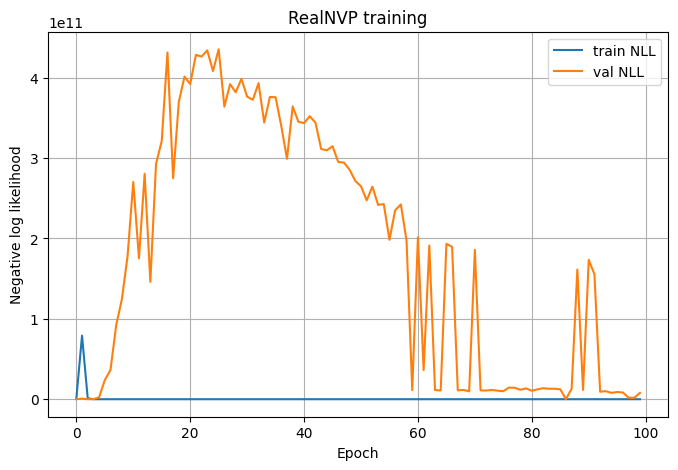

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(train_nll_history, label="train NLL")
plt.plot(val_nll_history, label="val NLL")
plt.xlabel("Epoch")
plt.ylabel("Negative log likelihood")
plt.title("RealNVP training")
plt.legend()
plt.grid(True)
plt.show()

## 17. Calcola anomaly scores

In [17]:
def compute_flow_scores(model, X, batch_size=4096):
    dataset = FlowDataset(X)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    model.eval()
    scores = []
    log_probs = []

    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)

            logp = model.log_prob(X_batch)
            nll = -logp

            scores.append(nll.cpu().numpy())
            log_probs.append(logp.cpu().numpy())

    return np.concatenate(scores), np.concatenate(log_probs)


scores_train, logp_train = compute_flow_scores(flow, A_train_norm)
scores_bg, logp_bg = compute_flow_scores(flow, A_bg_norm)
scores_sig, logp_sig = compute_flow_scores(flow, A_sig_norm)

print("NLL train mean/median:", scores_train.mean(), np.median(scores_train))
print("NLL bg mean/median:", scores_bg.mean(), np.median(scores_bg))
print("NLL sig mean/median:", scores_sig.mean(), np.median(scores_sig))

print("\nlogp train mean/median:", logp_train.mean(), np.median(logp_train))
print("logp bg mean/median:", logp_bg.mean(), np.median(logp_bg))
print("logp sig mean/median:", logp_sig.mean(), np.median(logp_sig))

NLL train mean/median: 1.5843377e+09 -41.76007
NLL bg mean/median: 2.3329524e+14 -41.14122
NLL sig mean/median: 1.6411771e+18 -5.1195946

logp train mean/median: -1.5843377e+09 41.76007
logp bg mean/median: -2.3329524e+14 41.14122
logp sig mean/median: -1.6411771e+18 5.1195946


## 18. ROC/AUC e plot

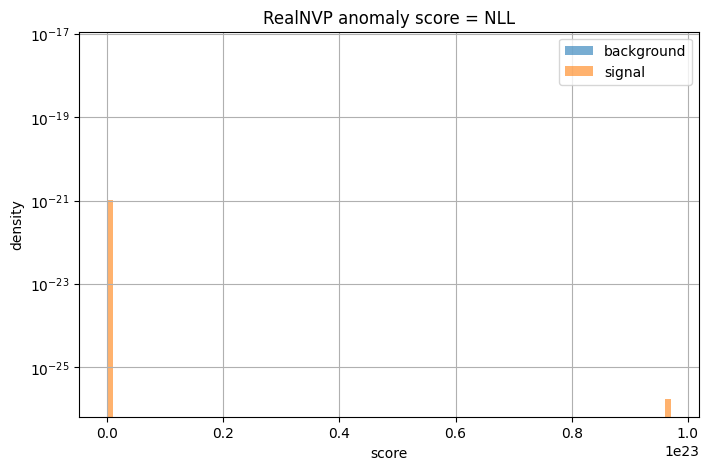


RealNVP NLL ROC
AUC: 0.8764770482362014
AUC inverted: 0.12352295176379854
Best AUC: 0.8764770482362014


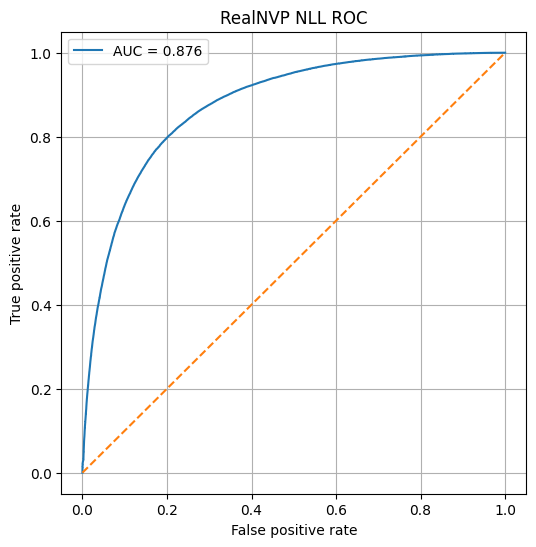

In [18]:
def evaluate_binary_scores(bg_scores, sig_scores, title):
    y_true = np.concatenate([
        np.zeros_like(bg_scores),
        np.ones_like(sig_scores),
    ])

    y_score = np.concatenate([
        bg_scores,
        sig_scores,
    ])

    auc = roc_auc_score(y_true, y_score)
    auc_inv = roc_auc_score(y_true, -y_score)
    best_auc = max(auc, auc_inv)

    print("\n" + title)
    print("AUC:", auc)
    print("AUC inverted:", auc_inv)
    print("Best AUC:", best_auc)

    if auc_inv > auc:
        plot_score = -y_score
        label = f"AUC inverted = {auc_inv:.3f}"
    else:
        plot_score = y_score
        label = f"AUC = {auc:.3f}"

    fpr, tpr, _ = roc_curve(y_true, plot_score)

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=label)
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    return auc, auc_inv, best_auc


def plot_score_distribution(bg_scores, sig_scores, title):
    plt.figure(figsize=(8, 5))
    plt.hist(bg_scores, bins=100, density=True, alpha=0.6, label="background")
    plt.hist(sig_scores, bins=100, density=True, alpha=0.6, label="signal")
    plt.yscale("log")
    plt.xlabel("score")
    plt.ylabel("density")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


plot_score_distribution(scores_bg, scores_sig, "RealNVP anomaly score = NLL")
auc_flow, auc_flow_inv, best_auc_flow = evaluate_binary_scores(
    scores_bg,
    scores_sig,
    "RealNVP NLL ROC",
)

## 19. Controllo train vs test background

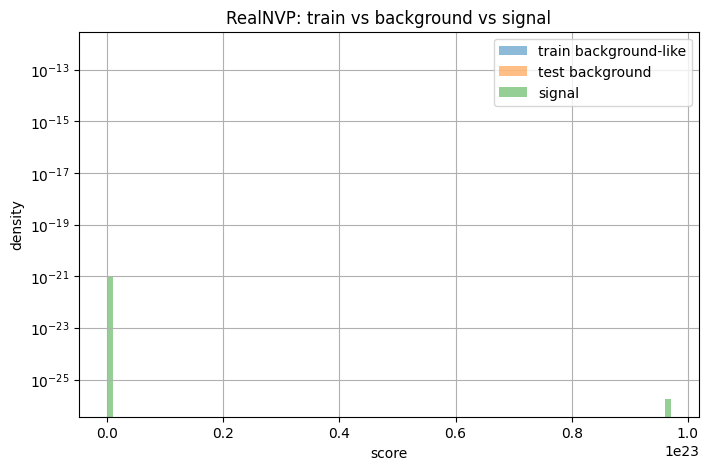

Train vs test background AUC: 0.5119277389
Train vs test background AUC inverted: 0.4880722611
Best train-vs-test-background AUC: 0.5119277389


In [19]:
def compare_train_bg_sig(train_scores, bg_scores, sig_scores, title):
    plt.figure(figsize=(8, 5))
    plt.hist(train_scores, bins=100, density=True, alpha=0.5, label="train background-like")
    plt.hist(bg_scores, bins=100, density=True, alpha=0.5, label="test background")
    plt.hist(sig_scores, bins=100, density=True, alpha=0.5, label="signal")
    plt.yscale("log")
    plt.xlabel("score")
    plt.ylabel("density")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    y = np.concatenate([
        np.zeros_like(train_scores),
        np.ones_like(bg_scores),
    ])

    s = np.concatenate([
        train_scores,
        bg_scores,
    ])

    auc_tb = roc_auc_score(y, s)
    auc_tb_inv = roc_auc_score(y, -s)

    print("Train vs test background AUC:", auc_tb)
    print("Train vs test background AUC inverted:", auc_tb_inv)
    print("Best train-vs-test-background AUC:", max(auc_tb, auc_tb_inv))

    return auc_tb, auc_tb_inv, max(auc_tb, auc_tb_inv)


auc_train_bg, auc_train_bg_inv, best_auc_train_bg = compare_train_bg_sig(
    scores_train,
    scores_bg,
    scores_sig,
    "RealNVP: train vs background vs signal",
)

## 20. Ablation rapida: track-only flow diagnostic

In [20]:
# Questo NON allena un secondo flow.
# Fa solo una diagnostica supervisionata sulle aggregate track-only,
# per capire se le tracce aggregate contengono già una forte separazione.

A_train_tracks_only = build_aggregate_matrix(
    X_jets_train,
    X_tracks_train,
    mask_train,
    use_jets=False,
    use_tracks=True,
)

A_bg_tracks_only = build_aggregate_matrix(
    X_jets_bg,
    X_tracks_bg,
    mask_bg,
    use_jets=False,
    use_tracks=True,
)

A_sig_tracks_only = build_aggregate_matrix(
    X_jets_sig_eval,
    X_tracks_sig_eval,
    mask_sig_eval,
    use_jets=False,
    use_tracks=True,
)

m = A_train_tracks_only.mean(axis=0, keepdims=True)
s = A_train_tracks_only.std(axis=0, keepdims=True)
s = np.maximum(s, 1e-8)

A_bg_tracks_only_norm = ((A_bg_tracks_only - m) / s).astype(np.float32)
A_sig_tracks_only_norm = ((A_sig_tracks_only - m) / s).astype(np.float32)

X_clf_to = np.concatenate([A_bg_tracks_only_norm, A_sig_tracks_only_norm], axis=0)
y_clf_to = np.concatenate([
    np.zeros(A_bg_tracks_only_norm.shape[0], dtype=np.int64),
    np.ones(A_sig_tracks_only_norm.shape[0], dtype=np.int64),
])

X_tr, X_te, y_tr, y_te = train_test_split(
    X_clf_to,
    y_clf_to,
    test_size=0.3,
    random_state=42,
    stratify=y_clf_to,
)

clf_to = LogisticRegression(max_iter=3000)
clf_to.fit(X_tr, y_tr)
proba_to = clf_to.predict_proba(X_te)[:, 1]
auc_track_only_logreg = roc_auc_score(y_te, proba_to)

print("Track-only supervised logistic regression AUC:", auc_track_only_logreg)

C:\Users\andre\AppData\Local\Temp\ipykernel_12452\961609136.py:11: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(valid_vals, axis=1, keepdims=True)
c:\Users\andre\Desktop\You_better_code\advanceml\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\andre\AppData\Local\Temp\ipykernel_12452\961609136.py:13: RuntimeWarning: All-NaN slice encountered
  median = np.nanmedian(valid_vals, axis=1, keepdims=True)
c:\Users\andre\Desktop\You_better_code\advanceml\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
C:\Users\andre\AppData\Local\Temp\ipykernel_12452\961609136.py:15: RuntimeWarning: All-NaN slice encountered
  maxv = np.nanmax(valid_vals, axis=1, keepdims=True)


Track-only supervised logistic regression AUC: 0.9894677834031028


## 21. Campionamento dal flow, sanity check opzionale

sampled shape: (5000, 75)
sampled finite: True
sampled mean/std: -1.3288115e+08 4.473629e+10


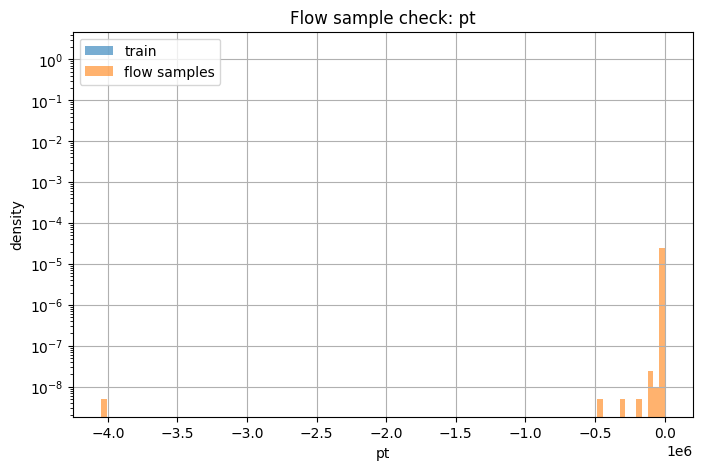

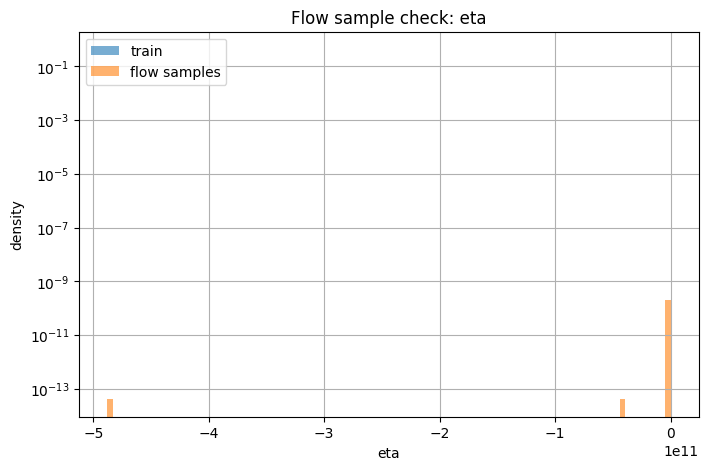

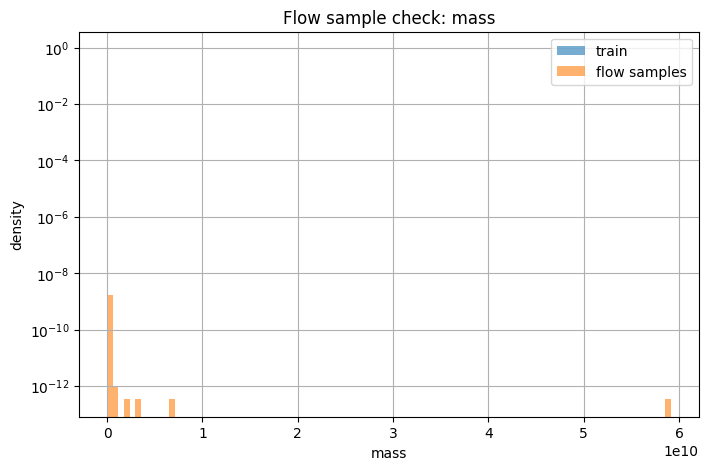

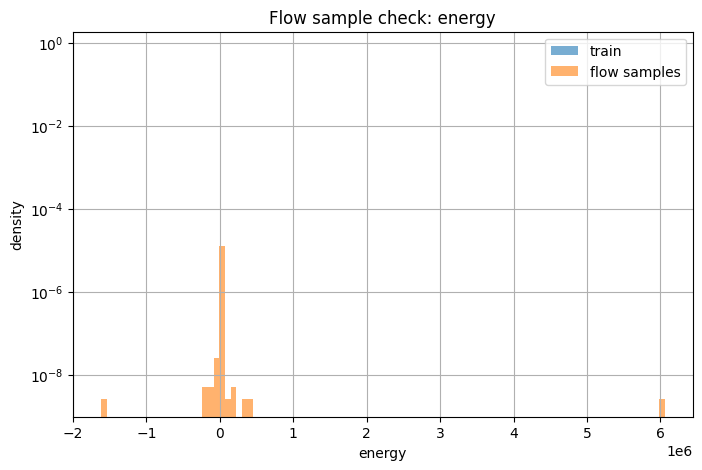

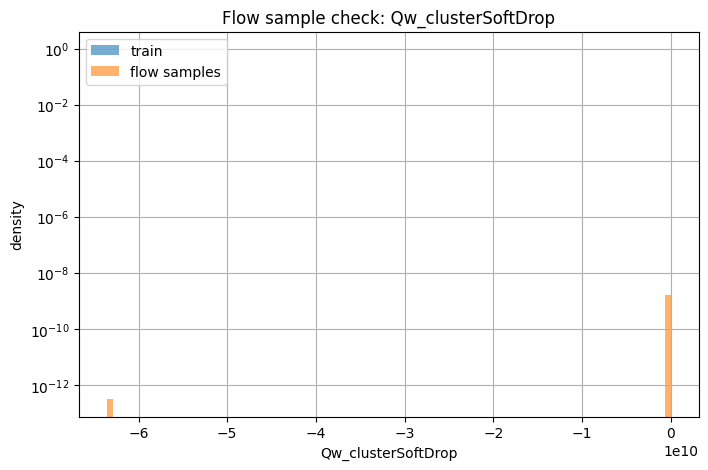

In [21]:
# Campiona punti dalla gaussiana latente e li riporta nello spazio delle feature normalizzate.
# Non è necessario per anomaly detection, ma serve come sanity check del generative model.

n_samples = 5000

flow.eval()
with torch.no_grad():
    z = torch.randn(n_samples, input_dim, device=device)
    x_sampled, _ = flow.inverse(z)
    x_sampled = x_sampled.cpu().numpy()

print("sampled shape:", x_sampled.shape)
print("sampled finite:", np.isfinite(x_sampled).all())
print("sampled mean/std:", x_sampled.mean(), x_sampled.std())

# Confronto su prime feature
for i in range(min(5, input_dim)):
    plt.figure(figsize=(8, 5))
    plt.hist(A_train_norm[:, i], bins=100, density=True, alpha=0.6, label="train")
    plt.hist(x_sampled[:, i], bins=100, density=True, alpha=0.6, label="flow samples")
    plt.yscale("log")
    plt.xlabel(aggregate_feature_names[i])
    plt.ylabel("density")
    plt.title(f"Flow sample check: {aggregate_feature_names[i]}")
    plt.legend()
    plt.grid(True)
    plt.show()

## 22. Salvataggio

In [22]:
torch.save(
    {
        "model_state_dict": flow.state_dict(),
        "input_dim": input_dim,
        "n_flow_layers": n_flow_layers,
        "hidden_dim": hidden_dim,
        "aggregate_feature_names": aggregate_feature_names,
        "agg_mean": agg_mean,
        "agg_std": agg_std,
        "train_nll_history": train_nll_history,
        "val_nll_history": val_nll_history,
        "auc_flow": auc_flow,
        "auc_flow_inv": auc_flow_inv,
        "best_auc_flow": best_auc_flow,
        "auc_train_bg": auc_train_bg,
        "auc_train_bg_inv": auc_train_bg_inv,
        "best_auc_train_bg": best_auc_train_bg,
        "auc_logreg": auc_logreg,
        "auc_track_only_logreg": auc_track_only_logreg,
    },
    OUTPUT_DIR / "realnvp_flow.pt",
)

np.savez_compressed(
    OUTPUT_DIR / "realnvp_flow_scores.npz",
    scores_train=scores_train,
    scores_bg=scores_bg,
    scores_sig=scores_sig,
    logp_train=logp_train,
    logp_bg=logp_bg,
    logp_sig=logp_sig,
    aggregate_feature_names=np.array(aggregate_feature_names, dtype=object),
    auc_flow=np.array(auc_flow, dtype=np.float32),
    auc_flow_inv=np.array(auc_flow_inv, dtype=np.float32),
    best_auc_flow=np.array(best_auc_flow, dtype=np.float32),
    auc_train_bg=np.array(auc_train_bg, dtype=np.float32),
    auc_train_bg_inv=np.array(auc_train_bg_inv, dtype=np.float32),
    best_auc_train_bg=np.array(best_auc_train_bg, dtype=np.float32),
    auc_logreg=np.array(auc_logreg, dtype=np.float32),
    auc_track_only_logreg=np.array(auc_track_only_logreg, dtype=np.float32),
)

config = {
    "USE_DISPLACED_PT_FRACTION": USE_DISPLACED_PT_FRACTION,
    "EVAL_ONLY_TRUE_DISPLACED_SIGNAL": EVAL_ONLY_TRUE_DISPLACED_SIGNAL,
    "USE_JET_FEATURES": USE_JET_FEATURES,
    "USE_TRACK_AGGREGATES": USE_TRACK_AGGREGATES,
    "jet_features": jet_feature_names,
    "track_features": track_feature_names,
    "processed_files": {k: str(v) for k, v in processed_files.items()},
    "input_dim": int(input_dim),
    "n_flow_layers": int(n_flow_layers),
    "hidden_dim": int(hidden_dim),
    "batch_size": int(batch_size),
    "n_epochs": int(n_epochs),
    "best_auc_flow": float(best_auc_flow),
    "best_auc_train_bg": float(best_auc_train_bg),
    "auc_logreg": float(auc_logreg),
    "auc_track_only_logreg": float(auc_track_only_logreg),
}

with open(OUTPUT_DIR / "realnvp_flow_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved:")
print(OUTPUT_DIR / "realnvp_flow.pt")
print(OUTPUT_DIR / "realnvp_flow_scores.npz")
print(OUTPUT_DIR / "realnvp_flow_config.json")

Saved:
outputs_flow\realnvp_flow.pt
outputs_flow\realnvp_flow_scores.npz
outputs_flow\realnvp_flow_config.json


## Note interpretative

Cose importanti da guardare:

1. **Best AUC flow**  
   Misura quanto il negative log-likelihood separa background e signal.

2. **Best train-vs-test-background AUC**  
   Deve essere vicino a 0.5. Se è alto, il flow distingue training background da test background: possibile domain shift.

3. **Single-feature AUC**  
   Se alcune singole feature separano già molto, il flow probabilmente sta solo modellando quella differenza.

4. **Track-only logistic regression AUC**  
   Se è alto, le tracce aggregate bastano quasi da sole.

5. **NLL più basso = più background-like**  
   Il nostro anomaly score è `NLL = -log p(x)`, quindi più alto significa più anomalo.